In [2]:
import torch
from torch.nn.functional import threshold

from models import ou_model, logistic_model, simulate, plot_traj_set

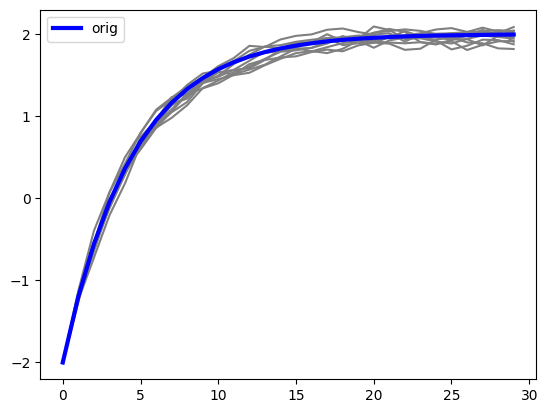

In [3]:
#ornstein uhlembeck process
# X_{t+1} = a*X_t + b + sigma*eps;  eps~normal(0,1)
time = 30
#fast convergence to x=2, with little noise
params = {'time': time,      # time steps
            'init_x':-2.,  # initial x
            'a': 0.88,        #
            'b': 0.24,       #
            'sigma': 0.22}

#slower convergence to x=2, higher variance
params2 = {'time': time,      # time steps
            'init_x':4.,  # initial x
            'a': 0.96,        #
            'b': 0.08,       #
            'sigma': 0.18}


params3 = {'time': time,      # time steps
            'init_x':0.,  # initial x
            'a': 0.9,        #
            'b': 0.0,       #
            'sigma': 0.4}

params4 = {'time': time,      # time steps
            'init_x':-2.,  # initial x
            'a': 0.8,        #
            'b': 0.4,       #
            'sigma': 0.22}

trajs = simulate(ou_model, 10000, params4)

plot_traj_set(trajs, single_traj=10, color='blue', label='orig')

In [4]:
#globally |x| < threshold per set di parametri 3, th = 0.7
#eventually X > threshold per set di parametri 1, th = 2.1
threshold = 2.1
row_max = trajs.max(dim=1).values
#row_min = trajs.min(dim=1).values
tv = (row_max > threshold).int()
#tv = tv * (row_min > -threshold).int()
tv.float().mean()

tensor(0.2897)

In [5]:
col_mu = trajs.mean(dim=0)
col_mu[-1]

tensor(1.9924)

In [16]:
# Calculate mean and variance for the event that in the last 5 steps X is between 1.95 and 2.05
lower, upper = 1.95, 2.05
last_five = trajs[:, -5:]

# Trajectory-level event: all last 5 values are inside [lower, upper]
event_last5_all = ((last_five >= lower) & (last_five <= upper)).all(dim=1).float()
prob_last5_all = event_last5_all.mean()
var_last5_all = event_last5_all.var(unbiased=False)

# Pointwise event over all samples x last-5 time points
event_pointwise_last5 = ((last_five >= lower) & (last_five <= upper)).float()
prob_pointwise_last5 = event_pointwise_last5.mean()
var_pointwise_last5 = event_pointwise_last5.var(unbiased=False)

print('Trajectory-level P(all last 5 in [1.95, 2.05]) =', prob_last5_all.item())
print('Trajectory-level Var(indicator) =', var_last5_all.item())
print('Pointwise P(in [1.95, 2.05] over last 5) =', prob_pointwise_last5.item())
print('Pointwise Var(indicator) =', var_pointwise_last5.item())

{'mean': prob_last5_all.item(), 'variance': var_last5_all.item()}

Trajectory-level P(all last 5 in [1.95, 2.05]) = 0.08240000158548355
Trajectory-level Var(indicator) = 0.07561024278402328
Pointwise P(in [1.95, 2.05] over last 5) = 0.46042001247406006
Pointwise Var(indicator) = 0.2484334260225296


{'mean': 0.08240000158548355, 'variance': 0.07561024278402328}

DeGAS section

In [8]:
# import module optimization to use DeGAS

import sys, os
sys.path.append(os.path.abspath(os.path.join('..')))

from optimization import *
import matplotlib.pyplot as plt
torch.set_default_dtype(torch.float64)

/home/rdoz/miniconda3/envs/myenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
# COMPILING AND SMOOTHING THE CFG

# Compile SOGA program to a smooth CFG
compiledFile = compile2SOGA('ou.soga')
cfg = produce_cfg(compiledFile)
smooth_cfg(cfg)

In [10]:
#run SOGA
output_dist = start_SOGA(cfg)

In [11]:
output_dist

Dist<['X', 'phi', 'count'],pi: tensor([[8.6245e-02],
        [3.5648e-02],
        [1.4861e-03],
        [1.0260e-02],
        [2.8253e-02],
        [7.1510e-03],
        [1.5684e-05],
        [6.8357e-04],
        [1.2107e-03],
        [9.9846e-03],
        [7.4175e-03],
        [4.2057e-04],
        [8.4728e-03],
        [2.9310e-02],
        [1.0627e-02],
        [7.9891e-05],
        [3.8857e-03],
        [7.1499e-03],
        [1.2150e-05],
        [1.1220e-05],
        [7.4949e-07],
        [1.4807e-04],
        [7.8263e-04],
        [3.8283e-04],
        [8.1731e-06],
        [5.3373e-04],
        [1.5178e-03],
        [2.8447e-02],
        [1.5391e-02],
        [7.2624e-04],
        [6.3940e-03],
        [1.8278e-02],
        [5.0138e-03],
        [1.3308e-05],
        [5.7946e-04],
        [1.0030e-03],
        [2.6759e-02],
        [2.0529e-02],
        [1.1902e-03],
        [2.9395e-02],
        [1.0651e-01],
        [4.1139e-02],
        [4.0250e-04],
        [2.0342e-02],
 

In [12]:
#average value of phi
mu = output_dist.gm.mean()[1]
var = output_dist.gm.cov()[1,1]
print(mu,var)
print(output_dist.gm.mean())
print(output_dist.gm.cov())


tensor(0.1065) tensor(0.0952)
tensor([ 1.9950,  0.1065, 30.0000])
tensor([[ 6.5071e-03,  3.7297e-04, -1.1409e-15],
        [ 3.7297e-04,  9.5163e-02,  7.4559e-16],
        [-1.1409e-15,  7.4559e-16,  1.0000e-06]])


In [13]:
output_dist.gm.mean()[1]

tensor(0.1065)

In [14]:
torch.mean(output_dist.gm.sigma[:,1,1])
#output_dist.gm.mu[:,1]

tensor(1.0000e-06)

In [15]:
output_dist

Dist<['X', 'phi', 'count'],pi: tensor([[8.6245e-02],
        [3.5648e-02],
        [1.4861e-03],
        [1.0260e-02],
        [2.8253e-02],
        [7.1510e-03],
        [1.5684e-05],
        [6.8357e-04],
        [1.2107e-03],
        [9.9846e-03],
        [7.4175e-03],
        [4.2057e-04],
        [8.4728e-03],
        [2.9310e-02],
        [1.0627e-02],
        [7.9891e-05],
        [3.8857e-03],
        [7.1499e-03],
        [1.2150e-05],
        [1.1220e-05],
        [7.4949e-07],
        [1.4807e-04],
        [7.8263e-04],
        [3.8283e-04],
        [8.1731e-06],
        [5.3373e-04],
        [1.5178e-03],
        [2.8447e-02],
        [1.5391e-02],
        [7.2624e-04],
        [6.3940e-03],
        [1.8278e-02],
        [5.0138e-03],
        [1.3308e-05],
        [5.7946e-04],
        [1.0030e-03],
        [2.6759e-02],
        [2.0529e-02],
        [1.1902e-03],
        [2.9395e-02],
        [1.0651e-01],
        [4.1139e-02],
        [4.0250e-04],
        [2.0342e-02],
 